# SmartCart Day 3 - Recognize & Diagnose

Detection found *where* products are; now we learn *what* each one is. We train a tiny linear head on frozen features, then **diagnose** it - per -class accuracy, confusions, and an explanation heatmap - because a checkout that silently misreads items is worse than useless.

In [1]:
# 1) Runtime setup
# This course runs in Google Colab. Run this cell first.
# Install only the packages used in this notebook.
%pip install -q timm

import os

# Drive stores the small cross-day bundle, not the image dataset.
#from google.colab import drive
#drive.mount('/content/drive')
#BUNDLE_DIR = '/content/drive/MyDrive/SmartCart'
BUNDLE_DIR = './data'


Note: you may need to restart the kernel to use updated packages.


### Embedded toolkit

This hidden cell defines the helper functions used below. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir
GROCERY_DATASET_URL = 'https://github.com/marcusklasson/GroceryStoreDataset'

class Bundle:
    """Small Google Drive folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir='/content/drive/MyDrive/SmartCart') -> Bundle:
    """Open the cross-day Drive bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def open_grocery_dataset():
    """Clone or reuse the real GroceryStoreDataset and return (tier, root_dir)."""
    root = HERE / 'GroceryStoreDataset'
    if (root / 'dataset' / 'classes.csv').exists():
        print('using cached GroceryStoreDataset:', root)
    else:
        print('cloning GroceryStoreDataset from:', GROCERY_DATASET_URL)
        subprocess.run(['git', 'clone', '--depth', '1', GROCERY_DATASET_URL, str(root)], check=True)
    if not (root / 'dataset' / 'classes.csv').exists():
        raise RuntimeError('GroceryStoreDataset clone is incomplete. Check Colab network access and rerun.')
    print('using data tier: github')
    print('data root:', root)
    print('OK: using real GroceryStoreDataset images.')
    return ('github', str(root))

def list_images(root, per_class=None):
    """Return a DataFrame with columns path,coarse,fine from GroceryStoreDataset train/val/test folders."""
    root = pathlib.Path(root)
    rows = []
    for split in ('train', 'val', 'test'):
        for p in (root / 'dataset' / split).rglob('*.jpg'):
            rows.append({'path': str(p), 'coarse': p.parent.parent.name, 'fine': p.parent.name})
    df = pd.DataFrame(rows)
    if per_class and len(df):
        df = df.groupby('fine', group_keys=False).head(per_class).reset_index(drop=True)
    return df

def load_backbone(name='vit_small_patch14_dinov2.lvd142m', device='cpu'):
    """Frozen DINOv2-small feature extractor."""
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0, dynamic_img_size=True).eval().to(device)
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def extract_features(model, batches, device=None) -> np.ndarray:
    """Run image batches through a frozen backbone and return numpy features."""
    import torch
    if device is None:
        try:
            device = next(model.parameters()).device
        except (AttributeError, StopIteration):
            device = 'cpu'
    outs = []
    with torch.no_grad():
        for xb in batches:
            y = model(xb.to(device))
            outs.append(y.detach().cpu().numpy().astype('float32'))
    return np.concatenate(outs, 0)

class LinearHead:
    """Tiny torch linear classifier trained on frozen image features."""

    def __init__(self, in_dim, n_classes):
        import torch
        import torch.nn as nn
        self.net = nn.Linear(in_dim, n_classes)
        self.torch = torch

    def fit(self, X, y, epochs=30, lr=0.01):
        t = self.torch
        opt = t.optim.Adam(self.net.parameters(), lr=lr)
        lossf = t.nn.CrossEntropyLoss()
        Xt = t.tensor(X)
        yt = t.tensor(y)
        for _ in range(epochs):
            opt.zero_grad()
            loss = lossf(self.net(Xt), yt)
            loss.backward()
            opt.step()
        return self

    def predict(self, X):
        with self.torch.no_grad():
            return self.net(self.torch.tensor(X)).argmax(1).numpy()

def save_head(head: LinearHead, path):
    import torch
    torch.save({'state_dict': head.net.state_dict(), 'in_dim': head.net.in_features, 'n_classes': head.net.out_features}, path)
    return path
# --- helpers are now available as plain functions/classes in this notebook ---
print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
# The bundle stores artifacts we create during the week: labels, indexes, weights, ONNX files.
# It is NOT the image dataset. Images are loaded in the next data-source cell.
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: data
artifacts: ['gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md', 'detector_synthetic_baseline.pt', 'head.onnx', 'crops_manifest_real.csv']


In [4]:
# 3) Select the image data source
# For class runs we require the real GroceryStoreDataset. If GitHub is unavailable, stop clearly.
tier, root = open_grocery_dataset()


using cached GroceryStoreDataset: c:\Users\drama\Desktop\^SIT- SNAIC\wk4-computer vision\project\GroceryStoreDataset
using data tier: github
data root: c:\Users\drama\Desktop\^SIT- SNAIC\wk4-computer vision\project\GroceryStoreDataset
OK: using real GroceryStoreDataset images.


## Load the training set (annotated images) + any detector crops

**What:** Re-list the balanced product images for *this* runtime; load Day 2's saved detector crops for a real-world check.

**Why:** The classifier learns from clean, balanced labels - not from however many crops the detector found. We re-list rather than trust saved paths because each day is a fresh VM.

**Watch for:** Detector crops live in the Drive bundle; if the count is 0, rerun Day 2 with the updated notebook.

In [5]:
import os
# Train from clean labelled product photos re-listed in this runtime.
per_class = int(os.environ.get('SC_PER_CLASS','40'))
data = list_images(root, per_class=per_class).rename(columns={'path':'crop_path'})
assert len(data) > 0, 'No GroceryStoreDataset images found. Re-run the data-source cell.'
print('training images:', len(data))
# Optional real-world check: Day 2 saved detector crops into the Drive bundle.
try:
    crops = b.get_table('crops_manifest.csv')
    crops = crops[crops.crop_path.apply(os.path.exists)]
    crops = crops if len(crops) else None
    print('detector crops available for a real-world check:', 0 if crops is None else len(crops))
except Exception:
    crops = None; print('no detector crops yet (Day 2 skipped) — training on annotated images only')


training images: 3232
detector crops available for a real-world check: 241


## Features + split

**What:** Embed every image, integer-encode the fine labels, and make a (guarded) stratified train/val split.

**Why:** Frozen features + a linear head is a strong, fast baseline; stratifying keeps rare classes in both sides.

**Watch for:** If any class has <2 samples we drop stratification automatically so the split never crashes.

In [6]:
import torch, torchvision.transforms.v2 as T
from PIL import Image
import numpy as np
# Shared image preprocessing for DINOv2.
TF = T.Compose([T.ToImage(), T.Resize((224,224)), T.ToDtype(torch.float32, scale=True),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
def feats_of(paths, model, bs=16):
    """Embed image files in small batches and return an (N, D) numpy array."""
    out=[]
    for i in range(0,len(paths),bs):
        xs=torch.stack([TF(Image.open(p).convert('RGB')) for p in paths[i:i+bs]])
        out.append(extract_features(model,[xs]))
    return np.concatenate(out,0)
from sklearn.model_selection import train_test_split
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)
model = load_backbone(device=device)
# Embed each image once, then train only a small linear classifier.
feats = feats_of(list(data.crop_path), model)
classes = sorted(data.fine.unique().tolist())
cls_to_i = {c:i for i,c in enumerate(classes)}
y = np.array([cls_to_i[f] for f in data.fine])
# Stratify only when every class has enough examples.
counts = np.bincount(y, minlength=len(classes))
strat = y if counts.min() >= 2 else None  # stratify only when every class has >=2 samples
Xtr,Xval,ytr,yval = train_test_split(feats, y, test_size=0.3, random_state=0, stratify=strat)
print('train', Xtr.shape, 'val', Xval.shape, '|', len(classes), 'classes')


using device: cuda


train (2262, 384) val (970, 384) | 81 classes


## Train the head

**What:** Fit the `LinearHead` on the training features and report validation accuracy.

**Why:** This is the actual product classifier - small enough to export and ship on Day 5.

**Watch for:** If val accuracy is near chance, features or labels are misaligned - stop and check.

In [7]:
head = LinearHead(in_dim=feats.shape[1], n_classes=len(classes)).fit(Xtr, ytr, epochs=200)
val_pred = head.predict(Xval)
# Simple top-1 validation accuracy.
acc = float((val_pred == yval).mean())
print('validation accuracy:', round(acc, 3))


validation accuracy: 0.944


## Error analysis

**What:** Build a confusion matrix, a per-class accuracy table, and surface the hardest confusions.

**Why:** Aggregate accuracy hides which SKUs fail; the checkout cares about *which* items it gets wrong.

**Watch for:** Low-n classes have noisy accuracy - read them alongside their support count.

,fine,acc,n
0,God-Morgon-Orange-Red-Grapefruit-Juice,0.750000,12
1,Red-Bell-Pepper,0.750000,12
2,Asparagus,0.818182,11
3,Alpro-Shelf-Soy-Milk,0.833333,12
4,Arla-Lactose-Medium-Fat-Milk,0.833333,12
...,...,...,...
76,Vine-Tomato,1.000000,12
77,Watermelon,1.000000,12
78,Yellow-Bell-Pepper,1.000000,12
79,Yellow-Onion,1.000000,12


,true,predicted,count
0,Arla-Natural-Mild-Low-Fat-Yoghurt,Arla-Natural-Yoghurt,2
1,Garant-Ecological-Medium-Fat-Milk,Garant-Ecological-Standard-Milk,2
2,Garant-Ecological-Standard-Milk,Garant-Ecological-Medium-Fat-Milk,2
3,God-Morgon-Orange-Red-Grapefruit-Juice,God-Morgon-Orange-Juice,2
4,Oatly-Oat-Milk,Garant-Ecological-Medium-Fat-Milk,2
5,Solid-Potato,Floury-Potato,2
6,Tropicana-Apple-Juice,Tropicana-Golden-Grapefruit,2
7,Yoggi-Vanilla-Yoghurt,Yoggi-Strawberry-Yoghurt,2
8,Alpro-Fresh-Soy-Milk,Alpro-Blueberry-Soyghurt,1
9,Alpro-Shelf-Soy-Milk,Alpro-Fresh-Soy-Milk,1


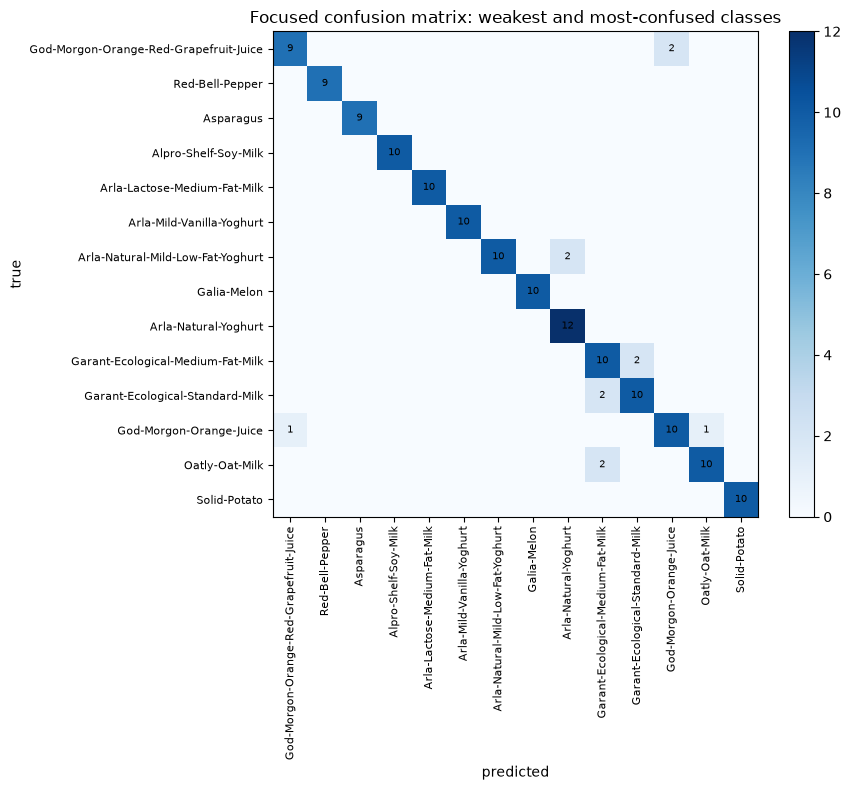

In [8]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
# Rows are true classes; columns are predicted classes.
cm = confusion_matrix(yval, val_pred, labels=list(range(len(classes))))
pcm = pd.DataFrame({
    'fine': classes,
    'acc': [cm[i,i]/cm[i].sum() if cm[i].sum() else 0.0 for i in range(len(classes))],
    'n': [int(cm[i].sum()) for i in range(len(classes))]})
display(pcm.sort_values(['acc','n']).reset_index(drop=True))
conf = [(classes[i], classes[j], int(cm[i,j])) for i in range(len(classes)) for j in range(len(classes)) if i!=j and cm[i,j]>0]
conf_df = pd.DataFrame(sorted(conf, key=lambda t:-t[2]), columns=['true','predicted','count'])
display(conf_df.head(12) if len(conf_df) else pd.DataFrame(columns=['true','predicted','count']))
# A full 81x81 matrix is unreadable. Plot a focused matrix around weak/confused classes.
weak = pcm.sort_values(['acc','n']).head(8).fine.tolist()
confused = list(dict.fromkeys(conf_df.head(8)[['true','predicted']].to_numpy().ravel().tolist())) if len(conf_df) else []
focus = list(dict.fromkeys(weak + confused))[:14]
focus_idx = [classes.index(c) for c in focus]
focus_cm = cm[np.ix_(focus_idx, focus_idx)]
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(focus_cm, cmap='Blues')
ax.set_xticks(range(len(focus))); ax.set_yticks(range(len(focus)))
ax.set_xticklabels(focus, rotation=90, fontsize=8); ax.set_yticklabels(focus, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Focused confusion matrix: weakest and most-confused classes')
for r in range(len(focus)):
    for c in range(len(focus)):
        if focus_cm[r,c]: ax.text(c, r, int(focus_cm[r,c]), ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## Close the loop: classify Day 2's real detector crops

**What:** Run the trained head on the actual crops the detector produced - clean-trained, real-tested.

**Why:** This is the real pipeline: a classifier trained on tidy labels must survive messy detections.

**Watch for:** Few crops at low detector epochs is expected; the number climbs with Day 2's full training.

In [9]:
if crops is not None and len(crops):
    cf = feats_of(list(crops.crop_path), model)
    pred = [classes[i] for i in head.predict(cf)]
    correct = sum(p==t for p,t in zip(pred, crops.fine))
    print(f'on {len(crops)} real detector crops: {correct}/{len(crops)} correct')
else:
    print('no detector crops to test (run Day 2 first).')


on 241 real detector crops: 218/241 correct


## Explain the call

**What:** Show a misread validation image and an occlusion heatmap that plays the same teaching role as Grad-CAM.

**Why:** The classifier head sits on frozen DINOv2 features, so occlusion is more robust here than forcing CNN-style Grad-CAM onto a ViT.

**Watch for:** Bright regions are patches where hiding pixels changes the predicted-class score most.

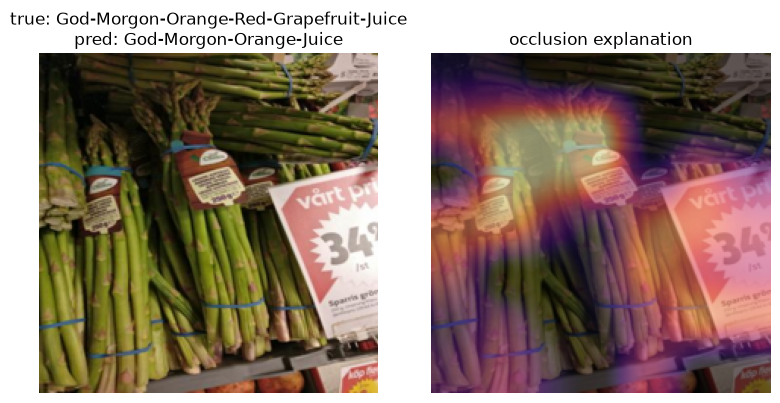

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
wrong = np.where(val_pred != yval)[0]
target = int(wrong[0]) if len(wrong) else 0
img_path = data.crop_path.iloc[target]
true_name = classes[int(yval[target])]
pred_name = classes[int(val_pred[target])]
img = Image.open(img_path).convert('RGB').resize((224,224))
base_feat = feats_of([img_path], model)
base_logits = head.net(head.torch.tensor(base_feat)).detach().numpy()[0]
pred_id = int(val_pred[target]); base_score = float(base_logits[pred_id])
heat = np.zeros((7,7), dtype='float32')
for r in range(7):
    for c in range(7):
        occ = img.copy()
        patch = Image.new('RGB', (32,32), color=(128,128,128))
        occ.paste(patch, (c*32, r*32))
        x = torch.stack([TF(occ)])
        f = extract_features(model, [x])
        score = float(head.net(head.torch.tensor(f)).detach().numpy()[0, pred_id])
        heat[r,c] = max(0.0, base_score - score)
heat = heat / (heat.max() + 1e-6)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title(f'true: {true_name}\npred: {pred_name}'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img); plt.imshow(Image.fromarray((heat*255).astype('uint8')).resize((224,224)), cmap='magma', alpha=0.55); plt.title('occlusion explanation'); plt.axis('off')
plt.tight_layout()


## Save + carry forward

**What:** Save the head, the per-class metrics, and a short error report into the bundle.

**Why:** Day 4 reads `head.pt` and `per_class_metrics.csv` to target the weakest classes.

**Watch for:** Confirm head.pt and per_class_metrics.csv are listed in the carry-forward print.

In [11]:
from pathlib import Path
save_head(head, str(Path(b.root)/'head.pt')); b._note('head.pt')
b.put_table('per_class_metrics.csv', pcm)
worst = pcm.sort_values('acc').head(3)
report = '# SmartCart Day 3 — Error Report\n\n' + \
    f'Validation accuracy: {acc:.3f}\n\n## Weakest classes\n\n' + \
    '```\n' + worst.to_string(index=False) + '\n```\n\n## Hardest confusions\n\n' + \
    '\n'.join(f'- {a} -> {bb} ({n})' for a,bb,n in sorted(conf, key=lambda t:-t[2])[:5])
(Path(b.root)/'error_report.md').write_text(report); b._note('error_report.md')
save_bundle(b)
print('\u25b6 Carries forward to Day 4: head.pt + per_class_metrics.csv')


[bundle] saved -> data
▶ Carries forward to Day 4: head.pt + per_class_metrics.csv


## Close the loop: real-world end-to-end accuracy (extension)

**What:** Run Day 2's real-photo crops through this classifier and check accuracy.

**Why:** This is the full pipeline test: detect on a real photo, then recognize the crop.

**Watch for:** `fine_true` comes from IoU-matching each crop back to its Label Studio ground-truth box - a crop with no `fine_true` means no annotated box matched it well (e.g. a spurious detection), not a labeling gap.

In [12]:
from pathlib import Path
real_crops_path = Path(b.root) / 'crops_manifest_real.csv'
if real_crops_path.exists():
    crops_real = b.get_table('crops_manifest_real.csv')
    labeled = crops_real.dropna(subset=['fine_true'])
    print(f'{len(labeled)}/{len(crops_real)} real crops have a matched ground-truth label')
    if len(labeled):
        cf_real = feats_of(list(labeled.crop_path), model)
        pred_real = [classes[i] for i in head.predict(cf_real)]
        correct = sum(p == t for p, t in zip(pred_real, labeled.fine_true))
        print(f'real-world end-to-end accuracy (detect -> recognize): {correct}/{len(labeled)} = {correct/len(labeled):.3f}')
    else:
        print('no real crops matched a ground-truth box yet - check that your Label Studio export used per-product labels, not a single generic one')
else:
    print('no real crops yet - run the Day 2 real-photo extension first')

1/1 real crops have a matched ground-truth label
real-world end-to-end accuracy (detect -> recognize): 0/1 = 0.000


## Improve the classifier with real photos (extension)

**What:** Add labeled real crops into the classifier's training data, refit a new head, and compare accuracy before/after.

**Why:** The previous cell only tested the existing classifier; this actually teaches it from your real photos, not just the clean dataset.

**Watch for:** Skips gracefully if there are too few labeled real crops to hold out a fair evaluation slice.

In [13]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import numpy as np
real_crops_path = Path(b.root) / 'crops_manifest_real.csv'
corrections_path = Path(b.root) / 'corrections_manifest.csv'
frames = []
if real_crops_path.exists():
    frames.append(b.get_table('crops_manifest_real.csv')[['crop_path', 'fine_true']])
if corrections_path.exists():
    frames.append(b.get_table('corrections_manifest.csv')[['crop_path', 'fine_true']])
if not frames:
    print('no real crops or corrections yet - run the Day 2 real-photo extension or use the Day 5b demo first')
else:
    crops_real2 = pd.concat(frames, ignore_index=True).drop_duplicates(subset='crop_path', keep='last')
    labeled2 = crops_real2.dropna(subset=['fine_true']).reset_index(drop=True)
    if len(labeled2) < 2:
        print(f'only {len(labeled2)} labeled real crop(s)/correction(s) found - need at least 2 to retrain (one train, one held-out). Label or correct more and re-run.')
    else:
        new_class_names = sorted(set(labeled2.fine_true.unique()) - set(classes))
        all_classes = sorted(set(classes) | set(new_class_names))
        cls_to_i2 = {c: i for i, c in enumerate(all_classes)}
        if new_class_names:
            counts = labeled2.fine_true.value_counts()
            for c in new_class_names:
                print(f'new product class detected: "{c}" ({counts.get(c, 0)} labeled example(s) - the classifier has zero prior examples for this class, so reliability scales with this count)')

        real_val_frac = 0.3 if len(labeled2) >= 4 else 1 / len(labeled2)
        real_train_df, real_holdout_df = train_test_split(labeled2, test_size=real_val_frac, random_state=0)
        real_train_feats = feats_of(list(real_train_df.crop_path), model)
        real_train_y = np.array([cls_to_i2[f] for f in real_train_df.fine_true])
        real_holdout_feats = feats_of(list(real_holdout_df.crop_path), model)
        real_holdout_y = np.array([cls_to_i2[f] for f in real_holdout_df.fine_true])

        ytr_names = [classes[i] for i in ytr]
        yval_names = [classes[i] for i in yval]
        ytr2_base = np.array([cls_to_i2[n] for n in ytr_names])
        yval2 = np.array([cls_to_i2[n] for n in yval_names])

        before_synth_acc = float((np.array([all_classes.index(classes[i]) for i in head.predict(Xval)]) == yval2).mean())
        before_real_acc = float((np.array([cls_to_i2.get(classes[i], -1) for i in head.predict(real_holdout_feats)]) == real_holdout_y).mean())

        Xtr2 = np.concatenate([Xtr, real_train_feats], axis=0)
        ytr2 = np.concatenate([ytr2_base, real_train_y], axis=0)
        head_v3 = LinearHead(in_dim=Xtr2.shape[1], n_classes=len(all_classes)).fit(Xtr2, ytr2, epochs=200)
        after_synth_acc = float((head_v3.predict(Xval) == yval2).mean())
        after_real_acc = float((head_v3.predict(real_holdout_feats) == real_holdout_y).mean())

        print(f'retrained on {len(real_train_df)} real crop(s)/correction(s), held out {len(real_holdout_df)} for evaluation')
        print(f'classes: {len(classes)} original -> {len(all_classes)} after adding {len(new_class_names)} new product(s)')
        print(f'synthetic val accuracy: before={before_synth_acc:.3f}  after={after_synth_acc:.3f}')
        print(f'real-photo accuracy (held-out): before={before_real_acc:.3f}  after={after_real_acc:.3f}')

        save_head(head_v3, str(Path(b.root) / 'head_v3.pt'))
        b._note('head_v3.pt')
        b.manifest['class_list'] = all_classes
        catalog = b.get_table('catalog_prices.csv')
        missing = [c for c in new_class_names if c not in set(catalog.fine)]
        if missing:
            new_rows = pd.DataFrame({'fine': missing, 'coarse': ['New'] * len(missing),
                                      'unit_price': [1.00] * len(missing), 'currency': ['USD'] * len(missing),
                                      'unit': ['each'] * len(missing)})
            catalog = pd.concat([catalog, new_rows], ignore_index=True)
            b.put_table('catalog_prices.csv', catalog)
            print(f'added {len(missing)} new product(s) to catalog_prices.csv with a placeholder $1.00 price - edit as needed')
        save_bundle(b)
        print('saved improved classifier -> head_v3.pt')

only 1 labeled real crop(s)/correction(s) found - need at least 2 to retrain (one train, one held-out). Label or correct more and re-run.
